In [3]:
import sys

!"{sys.executable}" -m ensurepip --upgrade
!"{sys.executable}" -m pip install matplotlib pandas numpy scipy

Looking in links: c:\Users\ANITS-~1\AppData\Local\Temp\tmpc4dh88qb
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------ --------------------- 4.5/9.5 MB 23.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 26.5 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------- -------------------------------- 7.1/37.3 MB 34.5 MB/s eta 0:00:01
   ------------ --------------------------- 11.5/37.3 MB 28.9 MB/s eta 0:00:01
   ---------------- ----------------------- 15.5/37.3 MB 25.3 MB/s eta 0:00:01
   -------------------- ------------------- 19.1/37.3 MB 23.5 MB/s eta 0:00:01
   ------------------------ --------------- 23.1/37.3 MB 22.6 MB/s eta 0:00:01
   ---------------------------- ----------- 27.0/37.3 MB 22.0 MB/s eta 0:00:01
   -------------------------------- ------- 30.1/37.3 MB 21.1 MB/s eta 0:00:01
   ----------------------------------- ---- 33.0/37.3 MB 20.0 MB/s eta 0:00:01
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,\N,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,\N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,\N,S


In [9]:
print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Number of Rows and Columns:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age                str
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [10]:
df.describe()

,PassengerId,Survived,Pclass,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,8.000000,6.000000,512.329200


In [14]:
Fare = df["Fare"].dropna()

In [15]:
mean = Fare.mean()

print("Mean =", mean)

Mean = 32.204207968574636


In [16]:
median = Fare.median()

print("Median =", median)

Median = 14.4542


In [17]:
mode = Fare.mode()

print("Mode =")
print(mode)

Mode =
0    8.05
Name: Fare, dtype: float64


In [18]:
variance = Fare.var()

print("Variance =", variance)

Variance = 2469.436845743116


In [19]:
std = Fare.std()

print("Standard Deviation =", std)

Standard Deviation = 49.6934285971809


In [20]:
Q1 = Fare.quantile(0.25)
Q2 = Fare.quantile(0.50)
Q3 = Fare.quantile(0.75)

print("Q1 =", Q1)
print("Q2 =", Q2)
print("Q3 =", Q3)

Q1 = 7.9104
Q2 = 14.4542
Q3 = 31.0


In [21]:
IQR = Q3 - Q1

print("Interquartile Range =", IQR)

Interquartile Range = 23.0896


In [22]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = Fare[(Fare < lower) | (Fare > upper)]

print(outliers)

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64


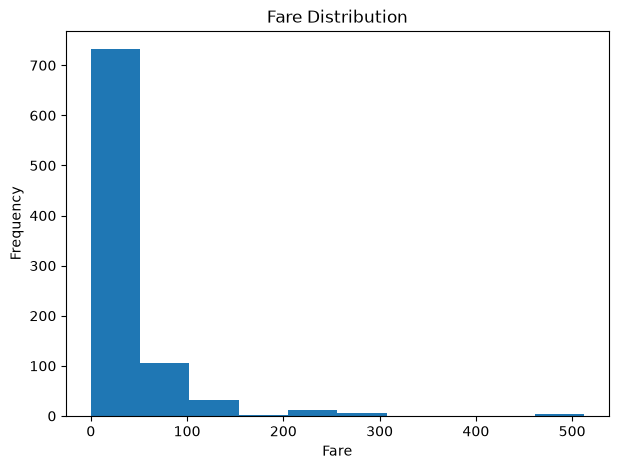

In [23]:
plt.figure(figsize=(7,5))

plt.hist(Fare, bins=10)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.show()

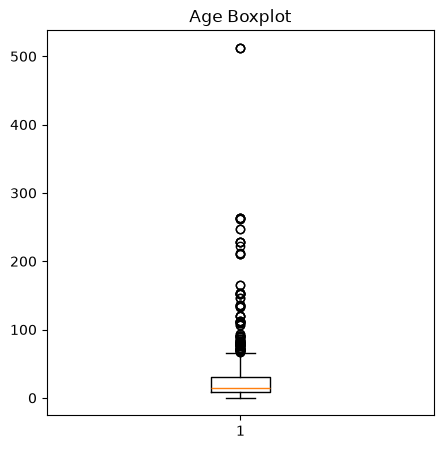

In [24]:
plt.figure(figsize=(5,5))

plt.boxplot(Fare)

plt.title("Age Boxplot")

plt.show()

In [25]:
clean_Fare = Fare[( Fare >= lower) & ( Fare <= upper)]

print(clean_Fare)

0       7.2500
2       7.9250
3      53.1000
4       8.0500
5       8.4583
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 775, dtype: float64


In [26]:
print("Original Mean =", Fare.mean())

print("Clean Mean =", clean_Fare.mean())

print("Original Standard Deviation =", Fare.std())

print("Clean Standard Deviation =", clean_Fare.std())

Original Mean = 32.204207968574636
Clean Mean = 17.82209070967742
Original Standard Deviation = 49.6934285971809
Clean Standard Deviation = 13.578085353787758


In [27]:
fare = df["Fare"]

In [28]:
fare.mean()

fare.median()

fare.mode()

fare.var()

fare.std()

fare.quantile(0.25)

fare.quantile(0.50)

fare.quantile(0.75)

np.float64(31.0)

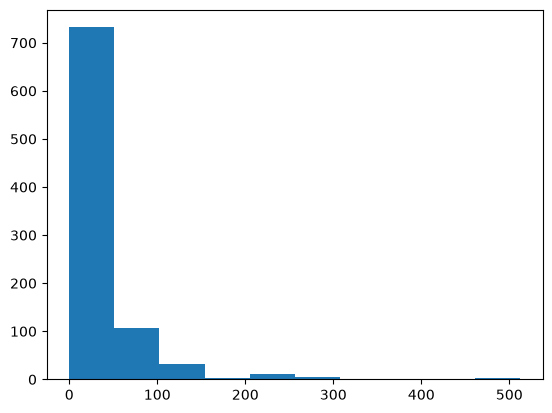

In [29]:
plt.hist(fare, bins=10)
plt.show()

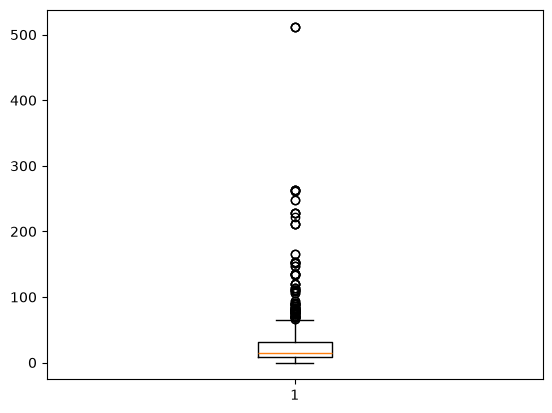

In [30]:
plt.boxplot(fare)
plt.show()